In [1]:
###-----------------
### Import libraries
###-----------------
from pathlib import Path  # Import Path for file system path operations and management
import numpy as np  # Import NumPy for numerical computations and array operations
import pandas as pd  # Import Pandas for data manipulation and analysis with DataFrames
import matplotlib.pyplot as plt  # Import Matplotlib for creating static, interactive visualizations
import seaborn as sns  # Import Seaborn for statistical data visualization built on Matplotlib

from sklearn.model_selection import train_test_split  # Import function to split dataset into training and testing subsets
from sklearn import datasets
from sklearn.metrics import (accuracy_score, 
                             classification_report, 
                             confusion_matrix, 
                             ConfusionMatrixDisplay, 
                             f1_score)  # Import function to calculate various metric


In [2]:
inpDir = Path('..') / '..' / 'input'

outDir = Path('..') / '..' / 'input'


RANDOM_STATE = 24

rng = np.random.default_rng(seed = RANDOM_STATE)

NOISE = 0.2
EPOCHS = 200
ALPHA = 0.001
N_SAMPLE = 1000
TEST_SIZE = 0.2

# Parameters for plotting
params = {'legend.fontsize': 'medium',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'large',
          'axes.titlesize':'large',
          'xtick.labelsize':'medium',
          'ytick.labelsize':'medium'
         }

CMAP = plt.cm.coolwarm

plt.rcParams.update(params)

plt.style.use('seaborn-v0_8-darkgrid') # plt.style.use('ggplot')

In [3]:
X, y = datasets.make_moons(n_samples=N_SAMPLE, 
                           noise=NOISE,
                           shuffle=True, 
                           random_state=RANDOM_STATE)
X[:5], y[:5]

(array([[ 0.90633951,  0.90267624],
        [-1.11536828,  0.75579289],
        [ 1.88769158,  0.4175967 ],
        [-0.93345034, -0.02299851],
        [-0.96872877,  0.06396285]]),
 array([0, 0, 1, 0, 0]))

In [4]:
data_df = pd.DataFrame(X, columns=['A', 'B'])
data_df["target"] = y

data_df.shape

(1000, 3)

<Axes: xlabel='A', ylabel='B'>

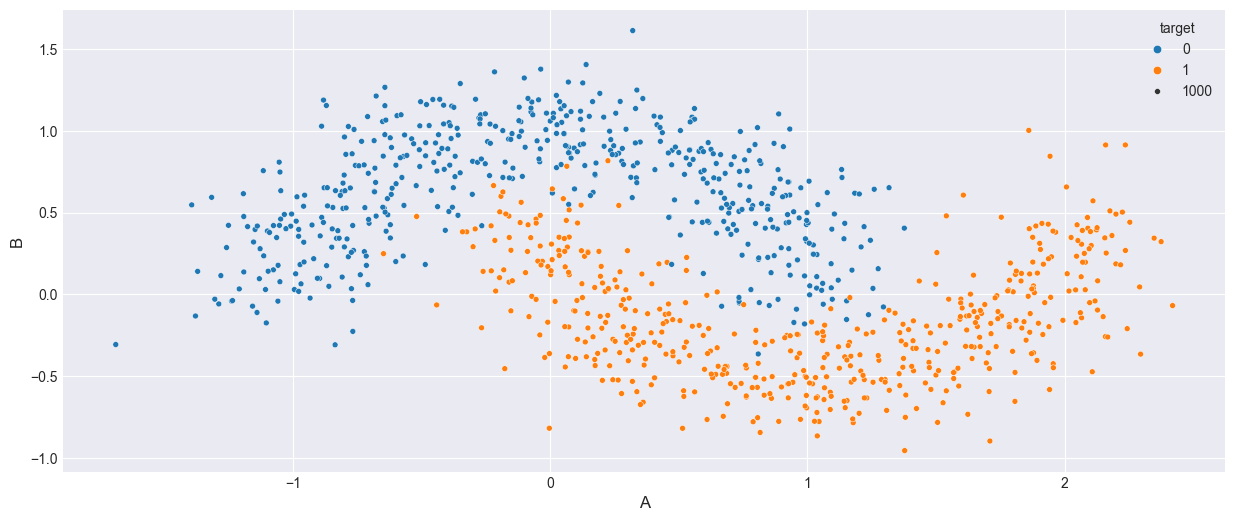

In [5]:
sns.scatterplot(data=data_df, 
                x="A", y="B",
                size=1000,
                hue="target")


In [6]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       1000 non-null   float64
 1   B       1000 non-null   float64
 2   target  1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [7]:
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
A,1000.0,0.490841,0.898951,-1.688795,-0.149565,0.500100,1.095048,2.419113
B,1000.0,0.239025,0.540082,-0.955280,-0.205090,0.241163,0.680394,1.612075
target,1000.0,0.500000,0.500250,0.000000,0.000000,0.500000,1.000000,1.000000


<Axes: xlabel='target'>

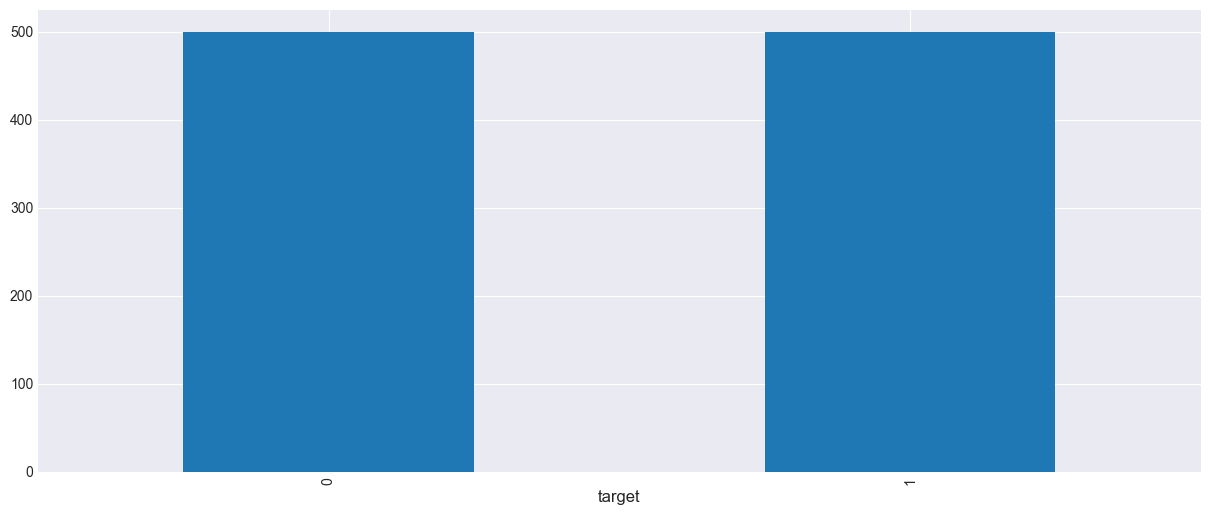

In [8]:
fig, ax = plt.subplots()

data_df['target'].value_counts().plot(ax=ax, kind='bar')

In [9]:
data_train, data_test = data_df.to_numpy()[ :900], data_df.to_numpy()[900:]
data_train.shape, data_test.shape

((900, 3), (100, 3))

In [10]:
def predict(row, weights):
    z = weights[0]

    for i in range(len(row)-1):
        z += weights[i + 1] * row[i]

    return 1 if z>=0 else 0  # Simplest activation

In [11]:
weights = np.array([0.1, 0.2, 1.0])

display(data_df.loc[0])

predict(data_df.loc[0].values, weights)

A         0.906340
B         0.902676
target    0.000000
Name: 0, dtype: float64

1

In [12]:
# rng.standard_normal(3)

In [13]:
# rng.normal(size=data_train.shape[1])

In [14]:
def train_weights(train, alpha=ALPHA, n_epochs= EPOCHS):
    errors = []

    weights = rng.standard_normal(train.shape[1])
    
    m = train.shape[0]

    for epoch in range(n_epochs):
        sum_error = 0.0
        for row in train:
            prediction = predict(row, weights)
            error = prediction - row[-1]
            sum_error += error**2
            weights[0] = weights[0] - alpha * error
            for i in range(len(row)-1):
                weights[i + 1] = weights[i + 1] - alpha* error * row[i]

        errors.append(sum_error / m)
        if epoch % 10 == 0:
            print(f'Epoch {epoch:3d}: Loss ={errors[-1]:.5f}')

    return errors, weights

In [15]:
errors, weights = train_weights(data_train, ALPHA, 200)

errors

Epoch   0: Loss =0.37111
Epoch  10: Loss =0.14333
Epoch  20: Loss =0.14000
Epoch  30: Loss =0.13889
Epoch  40: Loss =0.13889
Epoch  50: Loss =0.14000
Epoch  60: Loss =0.14444
Epoch  70: Loss =0.16889
Epoch  80: Loss =0.17778
Epoch  90: Loss =0.18000
Epoch 100: Loss =0.18444
Epoch 110: Loss =0.17556
Epoch 120: Loss =0.18222
Epoch 130: Loss =0.17778
Epoch 140: Loss =0.17889
Epoch 150: Loss =0.18222
Epoch 160: Loss =0.18444
Epoch 170: Loss =0.17333
Epoch 180: Loss =0.17111
Epoch 190: Loss =0.17889


[np.float64(0.3711111111111111),
 np.float64(0.24888888888888888),
 np.float64(0.19777777777777777),
 np.float64(0.17222222222222222),
 np.float64(0.15777777777777777),
 np.float64(0.14333333333333334),
 np.float64(0.13555555555555557),
 np.float64(0.14555555555555555),
 np.float64(0.14555555555555555),
 np.float64(0.14333333333333334),
 np.float64(0.14333333333333334),
 np.float64(0.14),
 np.float64(0.14),
 np.float64(0.1388888888888889),
 np.float64(0.1388888888888889),
 np.float64(0.13777777777777778),
 np.float64(0.13777777777777778),
 np.float64(0.14),
 np.float64(0.14),
 np.float64(0.14),
 np.float64(0.14),
 np.float64(0.1388888888888889),
 np.float64(0.14),
 np.float64(0.14),
 np.float64(0.14),
 np.float64(0.14),
 np.float64(0.14),
 np.float64(0.1388888888888889),
 np.float64(0.14),
 np.float64(0.14),
 np.float64(0.1388888888888889),
 np.float64(0.14),
 np.float64(0.1388888888888889),
 np.float64(0.14),
 np.float64(0.14),
 np.float64(0.1388888888888889),
 np.float64(0.14),
 np.f

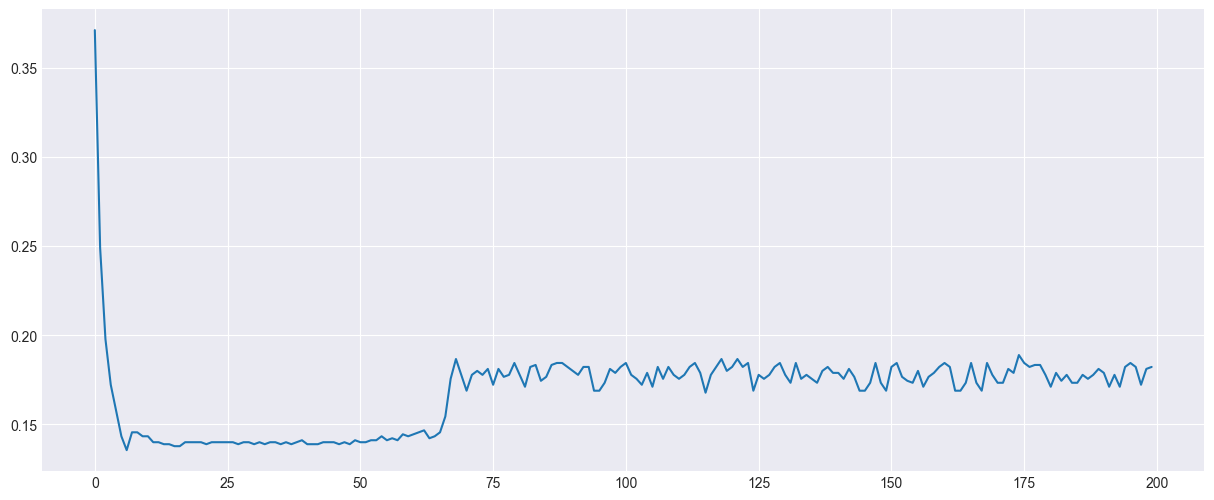

In [16]:
fig , ax = plt.subplots()
ax.plot(errors);

In [17]:
def plot_decision_boundary(X, wts):
    fig, ax = plt.subplots(figsize=(8, 5))
    dm = 0.01
    margin = 10*dm
    x_min, x_max = X[:, 0].min()-margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min()-margin, X[:, 1].max() + margin

    xx, yy = np.meshgrid(np.arange(x_min, x_max, dm),
                         np.arange(y_min, y_max, dm))
    
    X_data = np.c_[xx.ravel(), yy.ravel()]
    X_data = np.hstack((X_data, np.ones((X_data.shape[0],1))))
    y_pred = []
    for row in X_data:
        y_p = predict(row, wts)
        y_pred.append(y_p)

    Z = np.array(y_pred).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.6, cmap = plt.cm.Paired)
    ax.scatter(X[:,0], X[:,1], c=X[:,2], s = 2, cmap = plt.cm.Paired)

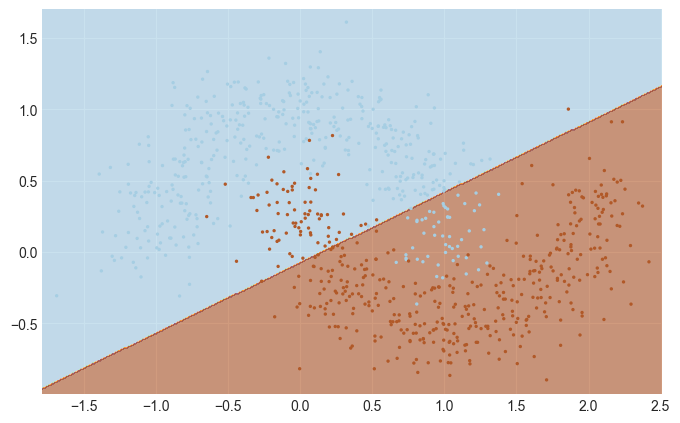

In [18]:
plot_decision_boundary(data_train, weights)

In [19]:
prediction = []

for row in data_train:
    pred = predict(row, weights)
    prediction.append(pred)

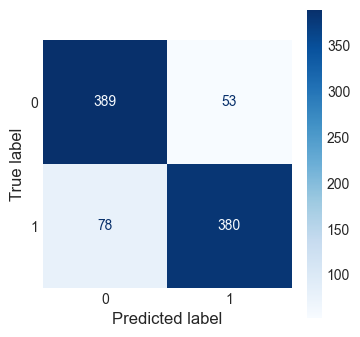

In [20]:
cm = confusion_matrix(y_true=data_train[:, -1], y_pred=prediction)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
fig, ax = plt.subplots(figsize=(4, 4))
disp.plot(ax=ax, cmap="Blues", colorbar=True)
ax.grid()


In [21]:
# y = [0, 1, 0]
# y_pred = [0, 1, 0]

# loss = 

In [22]:
def fn_sigmoid(z: np.float64):
    return 1 / (1 + np.exp(-z))

In [23]:
sm = fn_sigmoid(np.array([-np.inf, -1, 0 ,1, np.inf]))
sm

array([0.        , 0.26894142, 0.5       , 0.73105858, 1.        ])

In [24]:
def predict(row, weights):
    z = weights[0]

    for i in range(len(row)-1):
        z += weights[i + 1] * row[i]

    return fn_sigmoid(z) # Simplest activation

In [25]:
weights = np.array([0.1, 0.2, 1.0])

display(data_df.loc[0])

predict(data_df.loc[0].values, weights)

A         0.906340
B         0.902676
target    0.000000
Name: 0, dtype: float64

np.float64(0.7656562303990678)

In [26]:
def train_weights(train, alpha=ALPHA, n_epochs= EPOCHS):
    errors = []

    weights = rng.standard_normal(train.shape[1])
    
    m = train.shape[0]

    for epoch in range(n_epochs):
        sum_error = 0.0
        for row in train:
            a = predict(row, weights)
            dz = a - row[-1]


            error = -row[-1] * np.log(a) - (1 - row[-1]) * np.log(1 - a)
            # error = prediction - row[-1]

            sum_error += error
            weights[0] = weights[0] - alpha * dz
            for i in range(len(row)-1):
                weights[i + 1] = weights[i + 1] - alpha* dz * row[i]

        errors.append(sum_error / m)
        if epoch % 10 == 0:
            print(f'Epoch {epoch:3d}: Loss ={errors[-1]:.5f}')

    return errors, weights

In [27]:
errors, weights = train_weights(data_train)

Epoch   0: Loss =0.70283
Epoch  10: Loss =0.39880
Epoch  20: Loss =0.35435
Epoch  30: Loss =0.33496
Epoch  40: Loss =0.32370
Epoch  50: Loss =0.31631
Epoch  60: Loss =0.31116
Epoch  70: Loss =0.30744
Epoch  80: Loss =0.30468
Epoch  90: Loss =0.30259
Epoch 100: Loss =0.30098
Epoch 110: Loss =0.29974
Epoch 120: Loss =0.29876
Epoch 130: Loss =0.29799
Epoch 140: Loss =0.29737
Epoch 150: Loss =0.29687
Epoch 160: Loss =0.29647
Epoch 170: Loss =0.29614
Epoch 180: Loss =0.29587
Epoch 190: Loss =0.29565


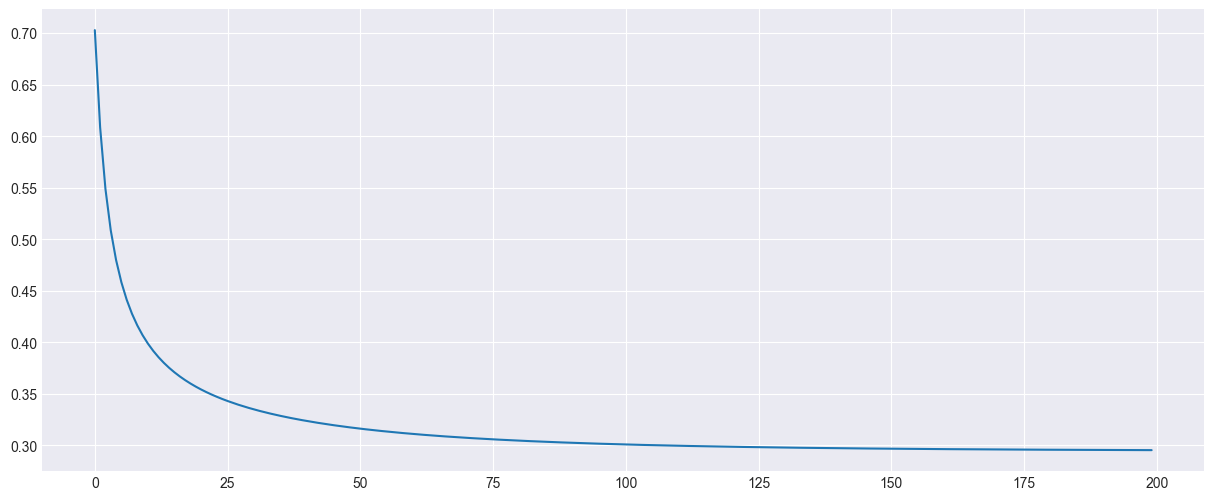

In [28]:
fig , ax = plt.subplots()
ax.plot(errors);

In [29]:
def fn_plot_decision_boundary(X, wts):
    fig, ax = plt.subplots(figsize=(8, 5))
    dm = 0.01
    margin = 10*dm
    x_min, x_max = X[:, 0].min()-margin, X[:, 0].max() + margin
    y_min, y_max = X[:, 1].min()-margin, X[:, 1].max() + margin

    xx, yy = np.meshgrid(np.arange(x_min, x_max, dm),
                         np.arange(y_min, y_max, dm))
    
    X_data = np.c_[xx.ravel(), yy.ravel()]
    X_data = np.hstack((X_data, np.ones((X_data.shape[0],1))))
    y_pred = []

    for row in X_data:
        y_p = predict(row, wts)
        y_pred.append(y_p)

    Z = np.array(y_pred).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.6, cmap = plt.cm.Paired)
    ax.scatter(X[:,0], X[:,1], c=X[:,2], s = 2, cmap = plt.cm.Paired)


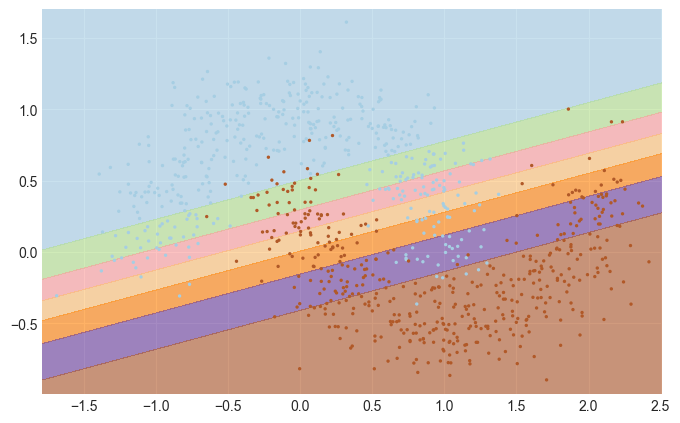

In [33]:
fn_plot_decision_boundary(data_train, weights)

In [32]:
predictions = []
for row in data_test:
    pred = predict(row, weights)
    predictions.append(pred)

# Use index -1 to get the 'target' column
accuracy_score(y_true=data_train[:, -1], y_pred=predictions)

ValueError: Found input variables with inconsistent numbers of samples: [900, 100]